In [ ]:
import numpy as np
import matplotlib.pyplot as plt

lst_mean = np.arange(200, 345, 10)
lst_std = np.arange(2, 11, 2) # set different LST std
num_pixel = 400
rounds = 10
error1, error2 = np.zeros((len(lst_mean), len(lst_std), 2)), np.zeros((len(lst_mean), len(lst_std), 2))

for j, lst_std_j in enumerate(lst_std):
    for i, lst_mean_i in enumerate(lst_mean):
        for seed in range(rounds):
            np.random.seed(seed)
            lst_random = np.random.normal(lst_mean_i, lst_std_j, (num_pixel))
            emi_random = np.random.uniform(0.8, 1, (num_pixel)) # Cheng 2014 RS

            lst_mean0 = (np.sum(emi_random * lst_random**4) / np.sum(emi_random)) ** 0.25
            lst_mean1 = (np.sum(lst_random**4) / num_pixel) ** 0.25
            lst_mean2 = np.mean(lst_random)

            error1[i,j,0] += np.abs(lst_mean1 - lst_mean0)
            error2[i,j,0] += np.abs(lst_mean2 - lst_mean0)

            # 
            emi_random = np.ones_like(lst_random)
            lst_mean0 = (np.sum(emi_random * lst_random**4) / np.sum(emi_random)) ** 0.25
            lst_mean1 = (np.sum(lst_random**4) / num_pixel) ** 0.25
            lst_mean2 = np.mean(lst_random)

            error1[i,j,1] += np.abs(lst_mean1 - lst_mean0)
            error2[i,j,1] += np.abs(lst_mean2 - lst_mean0)

error1 /= rounds
error2 /= rounds

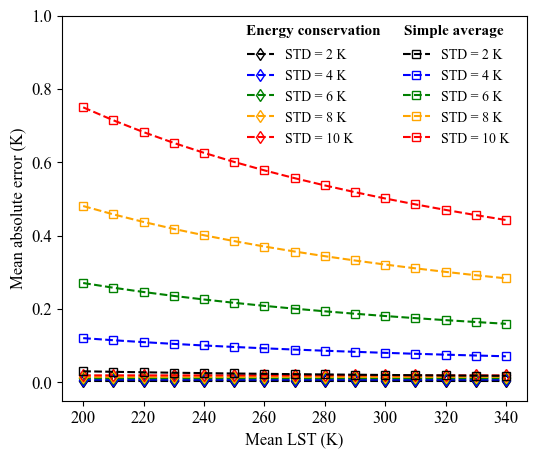

In [97]:
plt.rcParams['font.size'] = 12
plt.rcParams['font.family'] = 'Times New Roman'

colors = ['black', 'blue', 'green', 'orange', 'red']

fig, ax = plt.subplots(figsize=(6, 5))
for i in range(5):
    ax.plot(lst_mean, error1[:,i,0], marker='d', linestyle='--', color=colors[i], markerfacecolor='none', label=f'STD = {lst_std[i]} K')
for i in range(5):
    ax.plot(lst_mean, error2[:,i,0], marker='s', linestyle='--', color=colors[i], markerfacecolor='none', label=f'STD = {lst_std[i]} K', zorder=10)
# ax.plot(lst_mean, error2[...,1], marker='s', linestyle=':')

ax.set_xticks(np.arange(200, 351, 20))
ax.set_ylim([-0.05, 1])
ax.set_xlabel('Mean LST (K)')
ax.set_ylabel('Mean absolute error (K)')
ax.legend(ncols=2, fontsize=10, bbox_to_anchor=(0.37, 0.95), frameon=False, columnspacing=3.5)
ax.text(0.395, 0.95, "Energy conservation ", transform=ax.transAxes, fontsize=11, fontweight='bold')
ax.text(0.735, 0.95, "Simple average", transform=ax.transAxes, fontsize=11, fontweight='bold')

plt.savefig('figs/lst_degradation_accuracy.tif', dpi=300, bbox_inches='tight')